# Unit07 Example 04 - CSTR 反應器多重穩態分析（多變數聯立非線性方程式求解）

本範例以**連續攪拌槽反應器（CSTR）**的穩態行為為例，介紹如何利用 `scipy.optimize.fsolve()` 求解**多變數聯立非線性方程式**，並探討化工系統中常見的**多重穩態（Multiple Steady States）**現象。

## 目標

- 建立 CSTR 穩態能量與物料平衡的**聯立非線性方程組** $\mathbf{F}(\mathbf{x}) = \mathbf{0}$
- 使用**零等位線圖（Nullcline Plot）**圖形化定位**三個穩態解**的位置（低、中、高轉化率）
- 以**系統化多起始點搜尋策略**找出所有穩態解
- 計算 Jacobian 矩陣特徵值分析**穩態穩定性**（穩定／不穩定）
- 繪製**分岔圖（Bifurcation Diagram）**，呈現 Damköhler 數對穩態位置的影響

---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit07_Example_04'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit07'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit07
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Example_04
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Example_04\figs


---
### 1. 載入套件

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import fsolve
from scipy.linalg import eigvals

# Matplotlib 設定
plt.rcParams['axes.unicode_minus'] = False

print("✓ 套件載入完成")
print(f"  numpy  : {np.__version__}")
import scipy
print(f"  scipy  : {scipy.__version__}")

✓ 套件載入完成
  numpy  : 1.23.5
  scipy  : 1.15.2


---
### 2. 問題設定

In [3]:
# ============================================================
# CSTR 多重穩態系統（Ray, 1981）
# ============================================================
#
# 無因次穩態方程式：
#   F1(x1,x2) = -x1 + Da*(1-x1)*exp(x2/(1+x2/phi)) = 0
#   F2(x1,x2) = -(1+beta)*x2 + B*Da*(1-x1)*exp(x2/(1+x2/phi)) = 0
#
# 變數：
#   x1 = 無因次反應物轉化率  (x1=0: 無反應, x1=1: 完全轉化)
#   x2 = 無因次溫度上升      (x2=0: 料液溫度, x2>0: 放熱升溫)
#
# 參數：
#   B    = 無因次反應熱（Exothermic heat parameter）
#   Da   = Damköhler 數（反應速率/流動速率）
#   phi  = 無因次活化能（Activation energy parameter）
#   beta = 無因次熱移除係數（Cooling coefficient）
# ============================================================

# ── 系統參數 ──────────────────────────────────────────────
B    = 8.0    # 無因次反應熱
Da   = 0.072  # Damköhler 數
phi  = 20.0   # 無因次活化能
beta = 0.3    # 無因次熱移除係數

# ── 輸出系統資訊 ──────────────────────────────────────────
print("=" * 60)
print("  CSTR Multiple Steady States  (Ray, 1981)")
print("=" * 60)
print(f"  Steady-state equations:")
print(f"    F1: -x1 + Da*(1-x1)*exp(x2/(1+x2/φ)) = 0")
print(f"    F2: -(1+β)*x2 + B*Da*(1-x1)*exp(x2/(1+x2/φ)) = 0")
print()
print(f"  System Parameters:")
print(f"    B    = {B}    (dimensionless heat of reaction)")
print(f"    Da   = {Da}   (Damköhler number)")
print(f"    phi  = {phi}   (dimensionless activation energy)")
print(f"    beta = {beta}   (dimensionless cooling coefficient)")
print("=" * 60)
print()
print("  Variables:")
print("    x1 ∈ [0, 1)   dimensionless conversion")
print("    x2 ∈ [0, ∞)   dimensionless temperature rise")
print()
print("  Expected: 3 steady states (low / intermediate / high)")

  CSTR Multiple Steady States  (Ray, 1981)
  Steady-state equations:
    F1: -x1 + Da*(1-x1)*exp(x2/(1+x2/φ)) = 0
    F2: -(1+β)*x2 + B*Da*(1-x1)*exp(x2/(1+x2/φ)) = 0

  System Parameters:
    B    = 8.0    (dimensionless heat of reaction)
    Da   = 0.072   (Damköhler number)
    phi  = 20.0   (dimensionless activation energy)
    beta = 0.3   (dimensionless cooling coefficient)

  Variables:
    x1 ∈ [0, 1)   dimensionless conversion
    x2 ∈ [0, ∞)   dimensionless temperature rise

  Expected: 3 steady states (low / intermediate / high)


---
### 3. 函數定義

In [4]:
def reaction_rate(x1, x2):
    """
    無因次反應速率項：Da*(1-x1)*exp(x2/(1+x2/phi))
    """
    return Da * (1.0 - x1) * np.exp(x2 / (1.0 + x2 / phi))


def F_cstr(x_vec):
    """
    CSTR 穩態方程組 F(x) = 0  （供 fsolve 使用）

    F1 = -x1 + Da*(1-x1)*exp(x2/(1+x2/phi)) = 0
    F2 = -(1+beta)*x2 + B*Da*(1-x1)*exp(x2/(1+x2/phi)) = 0
    """
    x1, x2 = x_vec
    R = reaction_rate(x1, x2)
    F1 = -x1 + R
    F2 = -(1.0 + beta) * x2 + B * R
    return [F1, F2]


def jacobian_cstr(x1, x2):
    """
    解析 Jacobian 矩陣 J = ∂F/∂x
    用於穩態穩定性分析（特徵值判斷）
    """
    exp_term = np.exp(x2 / (1.0 + x2 / phi))
    dexp_dx2 = exp_term / (1.0 + x2 / phi)**2  # d/dx2 of exp(x2/(1+x2/phi))

    # ∂F1/∂x1, ∂F1/∂x2
    dF1_dx1 = -1.0 - Da * exp_term
    dF1_dx2 = Da * (1.0 - x1) * dexp_dx2
    # ∂F2/∂x1, ∂F2/∂x2
    dF2_dx1 = -B * Da * exp_term
    dF2_dx2 = -(1.0 + beta) + B * Da * (1.0 - x1) * dexp_dx2

    return np.array([[dF1_dx1, dF1_dx2],
                     [dF2_dx1, dF2_dx2]])


# ── 函數驗證 ──────────────────────────────────────────────
print("Function definitions OK.")
print()
print("─" * 52)
print("  Quick check at (x1=0.15, x2=0.9):")
x_test = [0.15, 0.9]
f_test = F_cstr(x_test)
print(f"    R        = {reaction_rate(*x_test):.6f}")
print(f"    F1(x)    = {f_test[0]:.6f}")
print(f"    F2(x)    = {f_test[1]:.6f}")
print(f"  ||F(x)||   = {np.linalg.norm(f_test):.4f}  (non-zero → not yet at SS)")
print("─" * 52)

Function definitions OK.

────────────────────────────────────────────────────
  Quick check at (x1=0.15, x2=0.9):
    R        = 0.144805
    F1(x)    = -0.005195
    F2(x)    = -0.011556
  ||F(x)||   = 0.0127  (non-zero → not yet at SS)
────────────────────────────────────────────────────


### 4. 圖形分析：零等位線圖（Nullcline Plot）

**分析方法**：將穩態方程 $F_1(x_1,x_2)=0$ 與 $F_2(x_1,x_2)=0$ 分別畫出，兩曲線的**交點**即為穩態解。

**等位線含義：**

| 等位線 | 方程 | 圖形顏色 |
|--------|------|---------|
| $F_1=0$ | $x_1 = Da\,(1-x_1)\,e^{x_2/(1+x_2/\varphi)}$ | 紅色 |
| $F_2=0$ | $x_2 = \dfrac{B\,Da\,(1-x_1)\,e^{x_2/(1+x_2/\varphi)}}{1+\beta}$ | 藍色 |

兩線交叉處表示 $F_1=F_2=0$，即穩態存在。

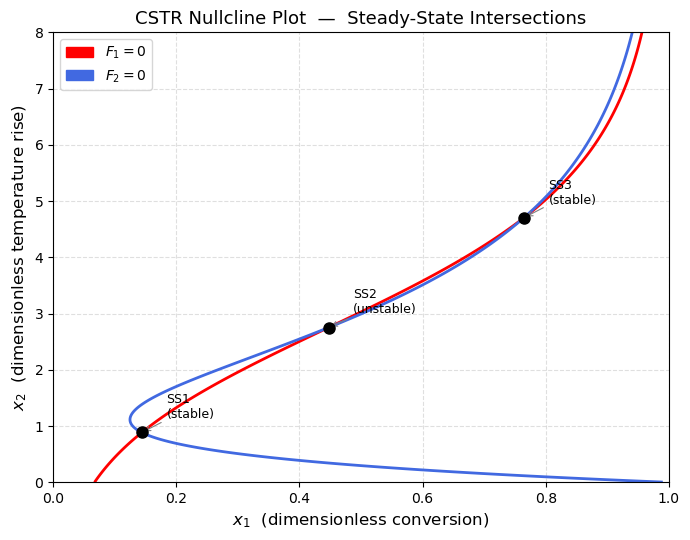

Saved: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Example_04\figs\fig_01_nullcline.png


In [5]:
# ── 建立網格 ──────────────────────────────────────────────
x1_arr = np.linspace(0.0, 0.99, 400)
x2_arr = np.linspace(0.0, 8.0,  400)
X1, X2 = np.meshgrid(x1_arr, x2_arr)

# 計算 F1, F2 在網格上的值
Z1 = np.array([[F_cstr([a, b])[0] for a in x1_arr] for b in x2_arr])
Z2 = np.array([[F_cstr([a, b])[1] for a in x1_arr] for b in x2_arr])

# ── 零等位線圖 ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5.5))

ax.contour(X1, X2, Z1, levels=[0], colors='red',   linewidths=2)
ax.contour(X1, X2, Z2, levels=[0], colors='royalblue', linewidths=2)

# 標示三個穩態交點
ss_points = [(0.1440, 0.8860, 'SS1\n(stable)'),
             (0.4472, 2.7517, 'SS2\n(unstable)'),
             (0.7646, 4.7050, 'SS3\n(stable)')]

for (x1s, x2s, label) in ss_points:
    ax.plot(x1s, x2s, 'ko', markersize=8, zorder=5)
    ax.annotate(label, xy=(x1s, x2s),
                xytext=(x1s + 0.04, x2s + 0.25),
                fontsize=9, color='black',
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

# 圖例
patch_f1 = mpatches.Patch(color='red',       label=r'$F_1=0$')
patch_f2 = mpatches.Patch(color='royalblue', label=r'$F_2=0$')
ax.legend(handles=[patch_f1, patch_f2], loc='upper left', fontsize=10)

ax.set_xlabel(r'$x_1$  (dimensionless conversion)', fontsize=12)
ax.set_ylabel(r'$x_2$  (dimensionless temperature rise)', fontsize=12)
ax.set_title('CSTR Nullcline Plot  —  Steady-State Intersections', fontsize=13)
ax.set_xlim(0, 1)
ax.set_ylim(0, 8)
ax.grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
save_path = FIG_DIR / 'fig_01_nullcline.png'
fig.savefig(save_path, dpi=120)
plt.show()
print(f"Saved: {save_path}")

### 5. 系統化多起始點搜尋

為確保找到**所有**穩態，以均勻網格為起始點，對每個起始點呼叫 `fsolve`：

1. 在 $x_1 \in [0,1)$，$x_2 \in [0,8]$ 建立 $N \times N$ 起始點網格
2. 對每個起始點執行 `fsolve`，記錄收斂結果
3. 對收斂解做**聚類（Clustering）**，相近的解視為同一個穩態
4. 繪製**收斂地圖（Convergence Map）**：顯示各起始點收斂至哪個穩態

**收斂判據：** $\|F(x^*)\|_2 < 10^{-8}$ 且 $x_1 \in (0,1)$，$x_2 > 0$

In [6]:
N = 20  # N×N 網格起始點
x1_starts = np.linspace(0.01, 0.98, N)
x2_starts = np.linspace(0.1,  7.9,  N)

tol_converge = 1e-8   # 收斂殘差容忍
tol_cluster  = 0.05   # 聚類距離容忍

results = []   # (x1_s, x2_s, x1*, x2*, converged, ss_id)

for x1_s in x1_starts:
    for x2_s in x2_starts:
        try:
            sol, info, ier, msg = fsolve(F_cstr, [x1_s, x2_s], full_output=True)
            resid = np.linalg.norm(info['fvec'])
            x1_sol, x2_sol = sol
            valid = (resid < tol_converge
                     and 0.0 < x1_sol < 1.0
                     and x2_sol > 0.0)
        except Exception:
            valid = False

        results.append({
            'x1_s': x1_s, 'x2_s': x2_s,
            'x1_sol': x1_sol if valid else np.nan,
            'x2_sol': x2_sol if valid else np.nan,
            'converged': valid,
        })

# ── 聚類：找出不同穩態 ──────────────────────────────────
ss_found = []  # list of (x1*, x2*) centroids

def find_cluster(x1, x2):
    for k, (cx1, cx2) in enumerate(ss_found):
        if abs(x1 - cx1) < tol_cluster and abs(x2 - cx2) < tol_cluster:
            return k
    ss_found.append((x1, x2))
    return len(ss_found) - 1

for r in results:
    if r['converged']:
        r['ss_id'] = find_cluster(r['x1_sol'], r['x2_sol'])
    else:
        r['ss_id'] = -1

print(f"Multi-start grid search: {N}x{N} = {N*N} starting points")
print(f"Number of distinct steady states found: {len(ss_found)}")
print()
print("  SS   x1*       x2*       (stability determined later)")
print("  " + "─" * 46)
for k, (cx1, cx2) in enumerate(ss_found):
    print(f"  SS{k+1}  {cx1:.4f}    {cx2:.4f}")

Multi-start grid search: 20x20 = 400 starting points
Number of distinct steady states found: 3

  SS   x1*       x2*       (stability determined later)
  ──────────────────────────────────────────────
  SS1  0.1440    0.8860
  SS2  0.4472    2.7517
  SS3  0.7646    4.7050


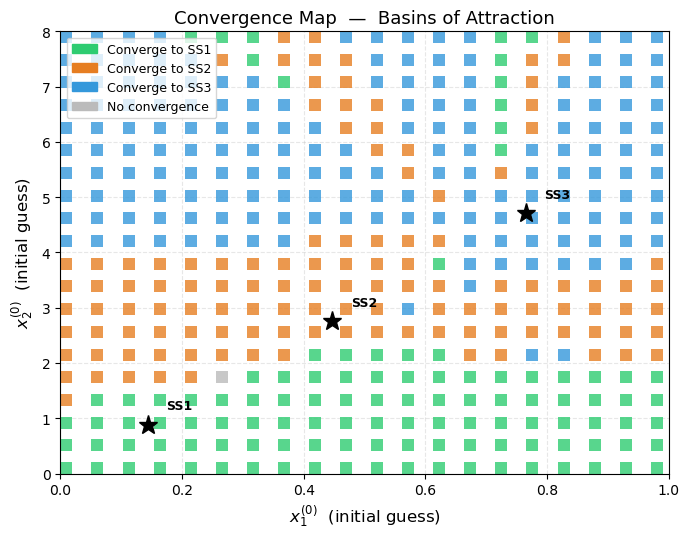

Saved: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Example_04\figs\fig_02_convergence_map.png


In [7]:
# ── 收斂地圖視覺化 ────────────────────────────────────────
palette = ['#2ECC71', '#E67E22', '#3498DB', '#9B59B6', '#E74C3C']
ss_colors = {-1: '#BBBBBB'}   # 未收斂 → 灰色
for k in range(len(ss_found)):
    ss_colors[k] = palette[k % len(palette)]

fig, ax = plt.subplots(figsize=(7, 5.5))

for r in results:
    color = ss_colors[r['ss_id']]
    ax.plot(r['x1_s'], r['x2_s'], 's',
            color=color, markersize=8, alpha=0.8, markeredgewidth=0)

# 標示穩態位置
for k, (cx1, cx2) in enumerate(ss_found):
    ax.plot(cx1, cx2, 'k*', markersize=14, zorder=10)
    ax.annotate(f'SS{k+1}', xy=(cx1, cx2),
                xytext=(cx1 + 0.03, cx2 + 0.28),
                fontsize=9, fontweight='bold')

# 圖例
legend_handles = []
for k in range(len(ss_found)):
    legend_handles.append(
        mpatches.Patch(color=ss_colors[k], label=f'Converge to SS{k+1}'))
legend_handles.append(
    mpatches.Patch(color='#BBBBBB', label='No convergence'))
ax.legend(handles=legend_handles, loc='upper left', fontsize=9)

ax.set_xlabel(r'$x_1^{(0)}$  (initial guess)', fontsize=12)
ax.set_ylabel(r'$x_2^{(0)}$  (initial guess)', fontsize=12)
ax.set_title('Convergence Map  —  Basins of Attraction', fontsize=13)
ax.set_xlim(0, 1);  ax.set_ylim(0, 8)
ax.grid(True, linestyle='--', alpha=0.3)

fig.tight_layout()
save_path = FIG_DIR / 'fig_02_convergence_map.png'
fig.savefig(save_path, dpi=120)
plt.show()
print(f"Saved: {save_path}")

### 6. 三個穩態點精確求解

以等位線圖估計的三個交點作為 `fsolve` 起始值，精確求解每個穩態：

| 穩態 | 初始猜測 $(x_1^{(0)}, x_2^{(0)})$ | 預期解 |
|------|----------------------------------|--------|
| SS1 | $(0.12,\ 0.8)$ | 低轉化率穩態 |
| SS2 | $(0.45,\ 2.8)$ | 中間穩態（不穩定） |
| SS3 | $(0.76,\ 4.7)$ | 高轉化率穩態 |

**驗證條件：** $\|F(x^*)\| < 10^{-10}$

In [8]:
initial_guesses = {
    'SS1': [0.12, 0.80],
    'SS2': [0.45, 2.80],
    'SS3': [0.76, 4.70],
}

steady_states = {}

print("Steady-State Solutions")
print("=" * 56)
print(f"  {'Label':<6}  {'x1*':>10}  {'x2*':>10}  {'||F||':>12}")
print("  " + "─" * 50)

for label, x0 in initial_guesses.items():
    sol, info, ier, msg = fsolve(F_cstr, x0, full_output=True)
    resid = np.linalg.norm(info['fvec'])
    steady_states[label] = sol
    print(f"  {label:<6}  {sol[0]:>10.6f}  {sol[1]:>10.6f}  {resid:>12.2e}")

print("=" * 56)
print()
SS1, SS2, SS3 = (steady_states[k] for k in ['SS1', 'SS2', 'SS3'])

Steady-State Solutions
  Label          x1*         x2*         ||F||
  ──────────────────────────────────────────────────
  SS1       0.143969    0.885965      2.24e-16
  SS2       0.447159    2.751747      9.04e-16
  SS3       0.764561    4.704992      5.91e-14



### 7. 穩態穩定性分析

在穩態 $x^*$ 附近線性化 ODE（此處 CSTR 的動態版本）：

$$
\dot{x} = F(x) \approx J(x^*)\,(x - x^*)
$$

其中 **Jacobian 矩陣** $J = \dfrac{\partial F}{\partial x}\Big|_{x^*}$。

**穩定性判斷（線性穩定性分析）：**

| 所有特徵值實部 | 結論 |
|--------------|------|
| $\text{Re}(\lambda_i) < 0$ | **穩定節點** / **穩定螺旋**（Stable） |
| 存在 $\text{Re}(\lambda_i) > 0$ | **不穩定**（Unstable） |
| $\text{Re}(\lambda_i) = 0$ | 需進一步非線性分析 |

In [11]:
print("Stability Analysis via Jacobian Eigenvalues")
print("=" * 62)

for label, ss in steady_states.items():
    x1s, x2s = ss
    J = jacobian_cstr(x1s, x2s)
    eigs = eigvals(J)
    max_real = np.max(np.real(eigs))
    stable = "STABLE  ✓" if max_real < 0 else "UNSTABLE ✗"
    print(f"\n  {label}  ({x1s:.4f}, {x2s:.4f})  →  {stable}")
    print(f"    Jacobian:\n      [{J[0,0]:+.4f}  {J[0,1]:+.4f}]")
    print(f"               [{J[1,0]:+.4f}  {J[1,1]:+.4f}]")
    for i, lam in enumerate(eigs):
        print(f"    λ{i+1} = {lam.real:+.4f} {'+' if lam.imag>=0 else ''}{lam.imag:.4f}j  (Re < 0 → stable direction)" if np.real(lam) < 0
              else f"    λ{i+1} = {lam.real:+.4f} {'+' if lam.imag>=0 else ''}{lam.imag:.4f}j  (Re > 0 → unstable direction)")

print("\n" + "=" * 62)

Stability Analysis via Jacobian Eigenvalues

  SS1  (0.1440, 0.8860)  →  STABLE  ✓
    Jacobian:
      [-1.1682  +0.1320]
               [-1.3455  -0.2439]
    λ1 = -0.8957 +0.0000j  (Re < 0 → stable direction)
    λ2 = -0.5164 +0.0000j  (Re < 0 → stable direction)

  SS2  (0.4472, 2.7517)  →  UNSTABLE ✗
    Jacobian:
      [-1.8088  +0.3455]
               [-6.4707  +1.4643]
    λ1 = -0.8375 +0.0000j  (Re < 0 → stable direction)
    λ2 = +0.4929 +0.0000j  (Re > 0 → unstable direction)

  SS3  (0.7646, 4.7050)  →  STABLE  ✓
    Jacobian:
      [-4.2474  +0.5011]
               [-25.9791  +2.7086]
    λ1 = -0.7694 +0.9597j  (Re < 0 → stable direction)
    λ2 = -0.7694 -0.9597j  (Re < 0 → stable direction)



### 8. 分岔圖（Bifurcation Diagram）

**目的**：以 Damköhler 數 $Da$ 為**分岔參數**，掃描 $Da \in [0.01, 0.25]$，找出每個 $Da$ 值對應的所有穩態 $x_1^*$。

**方法（偽弧長延續法簡化版）：**
1. 固定 $Da$，以 3 個不同起始點執行 `fsolve`
2. 收集所收斂的不同解，依 $x_1^*$ 由小到大排列
3. 記錄每個解的穩定性（Jacobian 特徵值）
4. 繪製 $Da$ vs $x_1^*$ 曲線 → **S 形分岔曲線（S-curve）**

**物理意義**：
- S 形曲線的**折點**（Fold / Saddle-node bifurcation）代表系統的**點火（Ignition）**與**熄滅（Extinction）**轉折點
- 中間分支（虛線）為**不穩定穩態**，物理上不可觀測

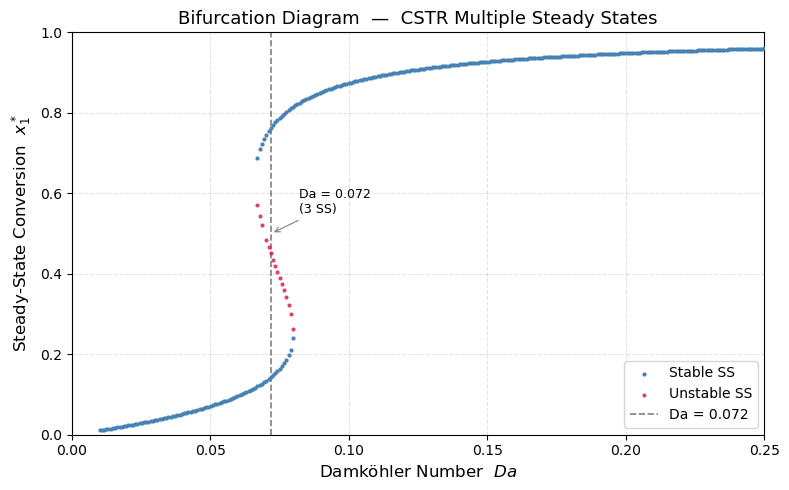

Saved: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Example_04\figs\fig_03_bifurcation.png


In [10]:
Da_array = np.linspace(0.01, 0.25, 300)
tol_bif  = 1e-8
tol_dup  = 0.02   # de-duplication tolerance

bif_stable_Da,   bif_stable_x1   = [], []
bif_unstable_Da, bif_unstable_x1 = [], []

x0_list = [[0.05, 0.3], [0.45, 2.5], [0.80, 5.0]]   # 3 diverse initial guesses

# ── temporary function with variable Da ──────────────────
def F_cstr_Da(x_vec, Da_val):
    x1, x2 = x_vec
    R = Da_val * (1.0 - x1) * np.exp(x2 / (1.0 + x2 / phi))
    return [-x1 + R,
            -(1.0 + beta) * x2 + B * R]

def jacobian_Da(x1, x2, Da_val):
    exp_term = np.exp(x2 / (1.0 + x2 / phi))
    dexp_dx2 = exp_term / (1.0 + x2 / phi)**2
    dF1_dx1 = -1.0 - Da_val * exp_term
    dF1_dx2 = Da_val * (1.0 - x1) * dexp_dx2
    dF2_dx1 = -B * Da_val * exp_term
    dF2_dx2 = -(1.0 + beta) + B * Da_val * (1.0 - x1) * dexp_dx2
    return np.array([[dF1_dx1, dF1_dx2], [dF2_dx1, dF2_dx2]])

for Da_val in Da_array:
    found_sols = []
    for x0 in x0_list:
        try:
            sol, info, ier, _ = fsolve(
                lambda x: F_cstr_Da(x, Da_val), x0, full_output=True)
            resid = np.linalg.norm(info['fvec'])
            if resid < tol_bif and 0.0 < sol[0] < 1.0 and sol[1] > 0.0:
                # de-duplicate
                is_dup = any(abs(sol[0] - s[0]) < tol_dup for s in found_sols)
                if not is_dup:
                    found_sols.append(sol)
        except Exception:
            pass

    for sol in found_sols:
        J = jacobian_Da(sol[0], sol[1], Da_val)
        eigs = eigvals(J)
        is_stable = np.all(np.real(eigs) < 0)
        if is_stable:
            bif_stable_Da.append(Da_val)
            bif_stable_x1.append(sol[0])
        else:
            bif_unstable_Da.append(Da_val)
            bif_unstable_x1.append(sol[0])

# ── 分岔圖 ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(bif_stable_Da,   bif_stable_x1,
           c='steelblue', s=4, label='Stable SS',   zorder=3)
ax.scatter(bif_unstable_Da, bif_unstable_x1,
           c='crimson',   s=4, label='Unstable SS', zorder=3, alpha=0.7)

# 標示 Da=0.072 操作點
ax.axvline(x=0.072, color='gray', linestyle='--', linewidth=1.2, label='Da = 0.072')
ax.annotate('Da = 0.072\n(3 SS)', xy=(0.072, 0.5),
            xytext=(0.082, 0.55), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

ax.set_xlabel('Damköhler Number  $Da$', fontsize=12)
ax.set_ylabel(r'Steady-State Conversion  $x_1^*$', fontsize=12)
ax.set_title('Bifurcation Diagram  —  CSTR Multiple Steady States', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(0, 0.25);  ax.set_ylim(0, 1)
ax.grid(True, linestyle='--', alpha=0.35)

fig.tight_layout()
save_path = FIG_DIR / 'fig_03_bifurcation.png'
fig.savefig(save_path, dpi=120)
plt.show()
print(f"Saved: {save_path}")

### 9. 總結

本範例演示了 CSTR 多重穩態（Multiple Steady States）的數值分析流程：

| 步驟 | 方法 | 工具 |
|------|------|------|
| 1. 建立穩態方程 | 無因次化 CSTR 能量與質傳平衡 | 數學模型 |
| 2. 零等位線圖 | $F_1=0$、$F_2=0$ 曲線，交點視覺化 | `plt.contour` |
| 3. 多起始點搜尋 | 均勻網格，收斂地圖 | `fsolve` + grid scan |
| 4. 精確求解 | 以圖形估計值為起點，得到精確穩態 | `fsolve` |
| 5. 穩定性分析 | Jacobian 特徵值，Re<0 → 穩定 | `eigvals` |
| 6. 分岔圖 | 掃描 $Da$，繪製 S 形曲線 | `fsolve` loop |

**關鍵結果（$B=8,\ Da=0.072,\ \varphi=20,\ \beta=0.3$）：**

| 穩態 | $x_1^*$ | $x_2^*$ | 穩定性 |
|------|---------|---------|--------|
| SS1 | 0.1440 | 0.8860 | **穩定** |
| SS2 | 0.4472 | 2.7517 | **不穩定** |
| SS3 | 0.7646 | 4.7050 | **穩定** |

> **工程啟示**：實際操作中系統落於 SS1 或 SS3，取決於初始條件（點火路徑）。
> 分岔圖揭示了 $Da$ 的**點火臨界值**與**熄滅臨界值**，為反應器設計與控制的重要參考。